# GBM for ETF Cross-Asset Rotation

Gradient boosting tests whether cross-asset rotation benefits from non-linear
feature interactions. The HMM stress state (31% of the sample from Ch9)
may interact with momentum in ways that linear models cannot capture -
for example, momentum reversals triggered by regime transitions. The grid
covers 5 leaf-count profiles × 3 loss functions = 15 configurations, with
IC evaluated at 50-iteration checkpoints to detect overfitting.

**Learning Objectives**:
- Compare tree depth profiles (7 to 63 leaves) on walk-forward CV
- Track IC learning curves to identify overfitting dynamics
- Determine whether non-linearity improves on the linear baseline
- Evaluate whether the 99-symbol cross-section is large enough for stable tree splits

**Book Reference**: Chapter 12, Section 12.8 (Case Study Results)

**Prerequisites**: `03_financial_features.py`, `04_temporal.py`, [`06_linear`](06_linear.ipynb)

In [1]:
"""GBM Grid Search - config-driven regularization profiles × loss functions."""

import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
import yaml

from case_studies.utils.gbm import (
    prepare_gbm_folds,
    register_gbm_result,
    train_gbm_config,
)
from case_studies.utils.registry import (
    build_training_spec,
    get_training_dir,
    load_prediction_metrics,
    load_prediction_sets,
    training_hash_from_spec,
    training_run_status,
)
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "etfs"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
MAX_FOLDS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
TRAIN_SAMPLE_FRAC = 1.0  # <1.0 subsamples training rows per fold (val is never sampled). Use for memory-constrained runs on large datasets.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]

# Device: read from setup.yaml, fall back to GPU detection
gbm_config = setup.get("modeling", {}).get("gbm", {})
DEVICE = gbm_config.get("device", "cuda")
MAX_BIN = 63  # GPU default
import torch

if DEVICE != "cpu" and not torch.cuda.is_available():
    DEVICE, MAX_BIN = "cpu", 255

print(f"Case study: {CASE_STUDY_ID} | Device: {DEVICE} | max_bin: {MAX_BIN}")

Case study: etfs | Device: gpu | max_bin: 63


## 1. Load Data and Model Configs

GBM configs are defined in `config/training/{label}.yaml` under the `gbm:` key.
Each config references a preset in `config/lgb/` with the complete
LightGBM parameter set. To modify the grid, edit the label config file.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"
splits = mds.splits[: MAX_FOLDS or None]

print(f"Dataset: {len(dataset):,} rows × {len(feature_names)} features")
print(f"Label: {label_col} | Task: {mds.task_type} | Folds: {len(splits)}")

Dataset: 394,233 rows × 71 features
Label: fwd_ret_21d | Task: regression | Folds: 8


In [5]:
configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, family="gbm")

print(f"\n{len(configs)} configs × {len(splits)} folds\n")
for cfg in configs:
    leaves = cfg["params"].get("num_leaves", 31)
    obj = cfg["params"].get("objective", "regression")
    n_trees = cfg.get("max_iterations", 500)
    print(f"  {cfg['config_name']:25s}  leaves={leaves:3d}  obj={obj}  trees={n_trees}")


15 configs × 8 folds

  default_mse                leaves= 31  obj=regression  trees=500
  default_mae                leaves= 31  obj=regression_l1  trees=500
  default_huber              leaves= 31  obj=huber  trees=500
  leaves_7_mse               leaves=  7  obj=regression  trees=500
  leaves_7_mae               leaves=  7  obj=regression_l1  trees=500
  leaves_7_huber             leaves=  7  obj=huber  trees=500
  leaves_15_mse              leaves= 15  obj=regression  trees=500
  leaves_15_mae              leaves= 15  obj=regression_l1  trees=500
  leaves_15_huber            leaves= 15  obj=huber  trees=500
  leaves_31_mse              leaves= 31  obj=regression  trees=500
  leaves_31_mae              leaves= 31  obj=regression_l1  trees=500
  leaves_31_huber            leaves= 31  obj=huber  trees=500
  leaves_63_mse              leaves= 63  obj=regression  trees=500
  leaves_63_mae              leaves= 63  obj=regression_l1  trees=500
  leaves_63_huber            leaves= 63  obj

## 2. Prepare CV Folds

GBM folds use float32 (LightGBM native precision) and skip
imputation/scaling - gradient boosting handles missing values natively.

In [6]:
dataset_pd = dataset.to_pandas()
fold_data = prepare_gbm_folds(
    dataset_pd,
    splits,
    feature_names,
    label_col,
    date_col,
    entity_col,
    task_type=mds.task_type,
    class_values=mds.class_values,
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
    train_sample_frac=TRAIN_SAMPLE_FRAC,
)

for f in fold_data:
    print(f"  Fold {f['fold']}: train={f['n_train']:,}  val={f['n_val']:,}")

  Fold 0: train=227,101  val=24,190
  Fold 1: train=222,805  val=23,940
  Fold 2: train=217,733  val=23,940
  Fold 3: train=210,654  val=23,942
  Fold 4: train=203,290  val=24,192
  Fold 5: train=192,472  val=24,186
  Fold 6: train=179,598  val=23,664
  Fold 7: train=157,397  val=22,180


## 3. Train All Configs

For each config, train one LightGBM model per fold to `max_iterations` trees.
Cross-sectional IC is evaluated at checkpoints (every 50 iterations) to
detect overfitting - configs that peak early and decay indicate too much capacity.

In [7]:
results = []
for cfg in configs:
    # Pre-compute registry training dir so boosters go directly there
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(fold_data),
        max_bin=MAX_BIN,
        checkpoint_interval=cfg.get("checkpoint_interval", 50),
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )
    train_dir = get_training_dir(CASE_STUDY_ID, spec)

    # Skip if this config's hash is already complete (unless FORCE_RETRAIN)
    _status = training_run_status(CASE_STUDY_ID, spec)
    _training_hash = training_hash_from_spec(spec)
    _split_rows = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=_training_hash,
        split=PREDICTION_SPLIT,
    )
    _split_complete = not _split_rows.is_empty()
    if _status.complete and _split_complete and not FORCE_RETRAIN:
        # Already trained + registered: rebuild a minimal result from the
        # registry so the grid + learning-curve sections render on a
        # fully-cached checkout. (A bare `continue` here drops the config
        # from `results`, printing an empty grid when every config is
        # registered.) best_ic is the authoritative registered value;
        # best_iter and the curves come from learning_curves.parquet.
        _pred_hash = _split_rows["prediction_hash"][0]
        _metrics = load_prediction_metrics(CASE_STUDY_ID, prediction_hash=_pred_hash)
        _best_ic = float(_metrics["ic_mean"][0]) if not _metrics.is_empty() else float("nan")
        # ic_n_days = number of validation dates that produced a defined daily IC.
        # A config that predicts near-constant on some folds yields no cross-sectional
        # IC on those dates and a partial ic_n_days below the full-coverage maximum.
        # Section 4 uses this to keep any partial-coverage config out of the ranking.
        _ic_n_days = float(_metrics["ic_n_days"][0]) if not _metrics.is_empty() else float("nan")
        _curves = []
        _lc_path = train_dir / "learning_curves.parquet"
        if _lc_path.exists():
            _curves = pl.read_parquet(_lc_path).to_dicts()
        _best_iter = 0
        if _curves:
            _best_iter = int(max(_curves, key=lambda c: c["ic_mean"])["iteration"])
        print(
            f"  {cfg['config_name']:25s}  iter={_best_iter:4d}  IC={_best_ic:+.4f}  "
            f"(cached, {_status.summary()})"
        )
        results.append(
            {
                "config_name": cfg["config_name"],
                "best_iter": _best_iter,
                "best_ic": _best_ic,
                "ic_n_days": _ic_n_days,
                "elapsed_s": 0.0,
                "learning_curves": _curves,
                "cached": True,
            }
        )
        continue
    if _status.complete and not _split_complete:
        print(f"  {cfg['config_name']:25s}  RETRAIN - missing {PREDICTION_SPLIT} predictions")
    elif _status.partial:
        print(f"  {cfg['config_name']:25s}  RETRAIN - partial state: {_status.summary()}")

    result = train_gbm_config(
        cfg,
        fold_data,
        feature_names=feature_names,
        device=DEVICE,
        max_bin=MAX_BIN,
        entity_col=entity_col,
        date_col=date_col,
        task_type=mds.task_type,
        class_values=mds.class_values,
        save_dir=train_dir,
    )
    results.append(result)
    print(
        f"  {result['config_name']:25s}  iter={result['best_iter']:4d}  "
        f"IC={result['best_ic']:+.4f}  ({result['elapsed_s']:.0f}s)"
    )

    # Register immediately after training - incremental save protects against
    # interruption losing work on large sweeps.
    register_gbm_result(
        CASE_STUDY_ID,
        result,
        cfg,
        label_col,
        n_folds=len(fold_data),
        max_bin=MAX_BIN,
        entry_point="07_gbm",
        date_col=date_col,
        entity_col=entity_col,
        train_sample_frac=TRAIN_SAMPLE_FRAC,
        prediction_split=PREDICTION_SPLIT,
    )

  default_mse                iter= 200  IC=+0.0155  (cached, complete (hash=ab10713af672))
  default_mae                iter=  50  IC=+0.0281  (cached, complete (hash=9b8d0d62422c))
  default_huber              iter= 200  IC=+0.0155  (cached, complete (hash=a5d3b55cc482))
  leaves_7_mse               iter= 250  IC=+0.0278  (cached, complete (hash=b4dbc2e98a77))
  leaves_7_mae               iter= 100  IC=+0.0440  (cached, complete (hash=d259643d2a2d))
  leaves_7_huber             iter= 250  IC=+0.0278  (cached, complete (hash=cd8f0c4c2235))
  leaves_15_mse              iter= 100  IC=+0.0246  (cached, complete (hash=d6addf7a3354))
  leaves_15_mae              iter=  50  IC=+0.0265  (cached, complete (hash=e595f259f0d0))
  leaves_15_huber            iter= 100  IC=+0.0246  (cached, complete (hash=3040ebdc3ea4))
  leaves_31_mse              iter=  50  IC=+0.0217  (cached, complete (hash=7c9cd3775519))
  leaves_31_mae              iter=  50  IC=+0.0276  (cached, complete (hash=6855c1f66909))

## 4. Grid Results

Configs are ranked by their validation IC. Each config's reported IC is its
**peak-checkpoint** value: for every config the tree count is tuned on the
validation folds by scanning the same 50-iteration checkpoint grid (50, 100,
..., 500) and keeping the checkpoint with the highest mean cross-sectional IC.
Because all configs share the identical checkpoint grid, this validation-based
choice of boosting rounds is comparable across the grid (it is the tree-count
analogue of early stopping) and does not favor one config over another. The
holdout is never touched here.

A full-coverage guard mirrors `06_linear` and `13_model_analysis`: a config that
collapses to near-constant predictions on some folds produces no cross-sectional
IC on those validation dates, so its IC is measured on fewer days (`ic_n_days`
below the full-coverage maximum) and is not comparable to a full-coverage IC.
Such configs are listed separately and excluded from the ranking and the winner.
On the frozen registry all 15 GBM configs are full-coverage, so the guard is
inert here - it hardens the notebook against a future partial-coverage config.

In [8]:
results.sort(key=lambda r: r["best_ic"] if np.isfinite(r["best_ic"]) else -np.inf, reverse=True)

# Full-coverage split (see markdown above). On a pure-retrain checkout ic_n_days is
# not yet known inline, so the guard falls back to the full result set.
_finite_days = [r["ic_n_days"] for r in results if np.isfinite(r.get("ic_n_days", np.nan))]
if _finite_days:
    _full_days = max(_finite_days)
    full_cov = [
        r
        for r in results
        if np.isfinite(r.get("ic_n_days", np.nan)) and r["ic_n_days"] == _full_days
    ]
    partial_cov = [r for r in results if r not in full_cov]
else:
    _full_days = None
    full_cov = results
    partial_cov = []

best = full_cov[0] if full_cov else None

print(f"{'Config':25s}  {'Iter':>5s}  {'IC':>8s}  {'N Days':>7s}")
print("-" * 52)
for r in full_cov:
    marker = " *" if r is best else ""
    _nd = r.get("ic_n_days", np.nan)
    _nd_str = f"{int(_nd):>7d}" if np.isfinite(_nd) else f"{'n/a':>7s}"
    print(f"  {r['config_name']:25s}  {r['best_iter']:5d}  {r['best_ic']:+.4f}  {_nd_str}{marker}")

if partial_cov:
    print("\nPartial coverage (degenerate on some folds - excluded from ranking):")
    for r in partial_cov:
        _nd = r.get("ic_n_days", np.nan)
        _nd_str = f"{int(_nd)}" if np.isfinite(_nd) else "n/a"
        print(
            f"  {r['config_name']:25s}  IC={r['best_ic']:+.4f}  "
            f"n_days={_nd_str} (of {int(_full_days)})"
        )

if best:
    print(
        f"\nBest (full coverage): {best['config_name']} @ {best['best_iter']} trees "
        f"(IC={best['best_ic']:+.4f})"
    )

Config                      Iter        IC   N Days
----------------------------------------------------
  leaves_7_mae                 100  +0.0440     2016 *
  leaves_63_mae                 50  +0.0310     2016
  default_mae                   50  +0.0281     2016
  leaves_7_mse                 250  +0.0278     2016
  leaves_7_huber               250  +0.0278     2016
  leaves_31_mae                 50  +0.0276     2016
  leaves_15_mae                 50  +0.0265     2016
  leaves_15_mse                100  +0.0246     2016
  leaves_15_huber              100  +0.0246     2016
  leaves_31_mse                 50  +0.0217     2016
  leaves_31_huber               50  +0.0217     2016
  leaves_63_mse                 50  +0.0181     2016
  leaves_63_huber               50  +0.0181     2016
  default_mse                  200  +0.0155     2016
  default_huber                200  +0.0155     2016

Best (full coverage): leaves_7_mae @ 100 trees (IC=+0.0440)


### IC by configuration

The bar chart ranks the full-coverage GBM configs by validation IC, colored by
loss function. MAE-loss configs cluster at the top and squared-error/Huber
configs trail, so the choice of loss matters more than tree depth on this
cross-section.

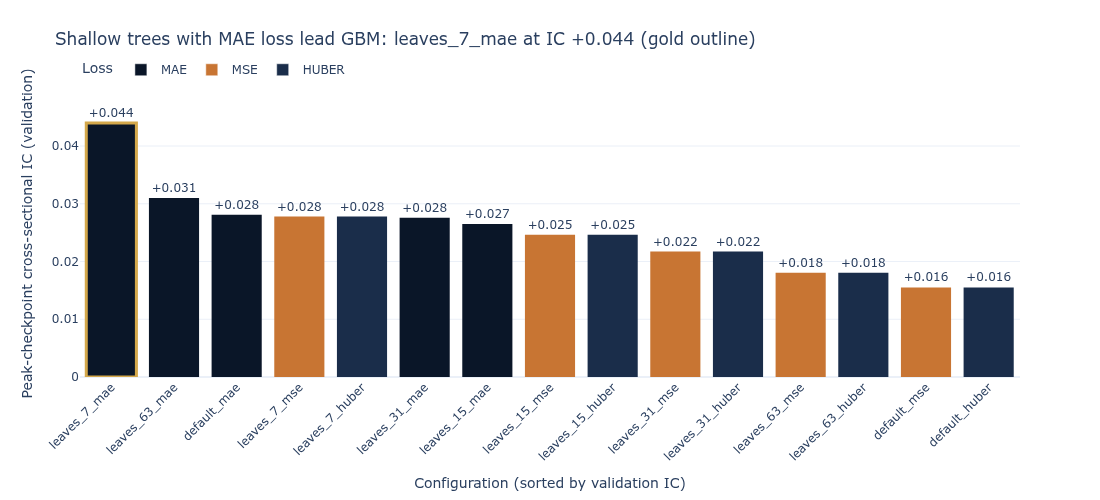

In [9]:
# Figure 1 - IC-by-config bar, colored by loss, winner outlined.
_LOSS_COLOR = {"mae": COLORS["blue"], "mse": COLORS["copper"], "huber": COLORS["slate"]}


def _loss_of(name: str) -> str:
    for loss in ("mae", "mse", "huber"):
        if name.endswith(loss):
            return loss
    return "other"


_names = [r["config_name"] for r in full_cov]
_ics = [r["best_ic"] for r in full_cov]
_losses = [_loss_of(n) for n in _names]
_leader = best["config_name"] if best else None
_bar_colors = [_LOSS_COLOR.get(loss, COLORS["silver"]) for loss in _losses]
_line_w = [3 if n == _leader else 0 for n in _names]
fig_ic = go.Figure(
    go.Bar(
        x=_names,
        y=_ics,
        marker=dict(color=_bar_colors, line=dict(color=COLORS["amber"], width=_line_w)),
        text=[f"{v:+.3f}" for v in _ics],
        textposition="outside",
        cliponaxis=False,
        showlegend=False,
    )
)
# Legend proxies for the three loss functions.
for loss in ("mae", "mse", "huber"):
    fig_ic.add_trace(
        go.Bar(
            x=[None],
            y=[None],
            marker_color=_LOSS_COLOR[loss],
            name=loss.upper(),
            showlegend=True,
        )
    )
_lead_ic = best["best_ic"] if best else float("nan")
fig_ic.update_layout(
    title=(f"Shallow trees with MAE loss lead GBM: {_leader} at IC {_lead_ic:+.3f} (gold outline)"),
    template="plotly_white",
    height=500,
    width=1100,
    barmode="overlay",
    legend=dict(title="Loss", orientation="h", yanchor="bottom", y=1.02, x=0),
    margin=dict(t=90),
)
fig_ic.update_xaxes(title_text="Configuration (sorted by validation IC)", tickangle=-45)
fig_ic.update_yaxes(title_text="Peak-checkpoint cross-sectional IC (validation)")
fig_ic.show()

## 5. Learning Curves

Validation IC at each 50-iteration checkpoint traces the overfitting dynamics.
The winner and the deep-tree configs peak early and then decay - added capacity
fits fold-specific noise rather than transferable cross-sectional structure -
while the shallow-tree configs stay flatter, the signature of adequate
regularization. The vertical line marks the winner's selected tree count.

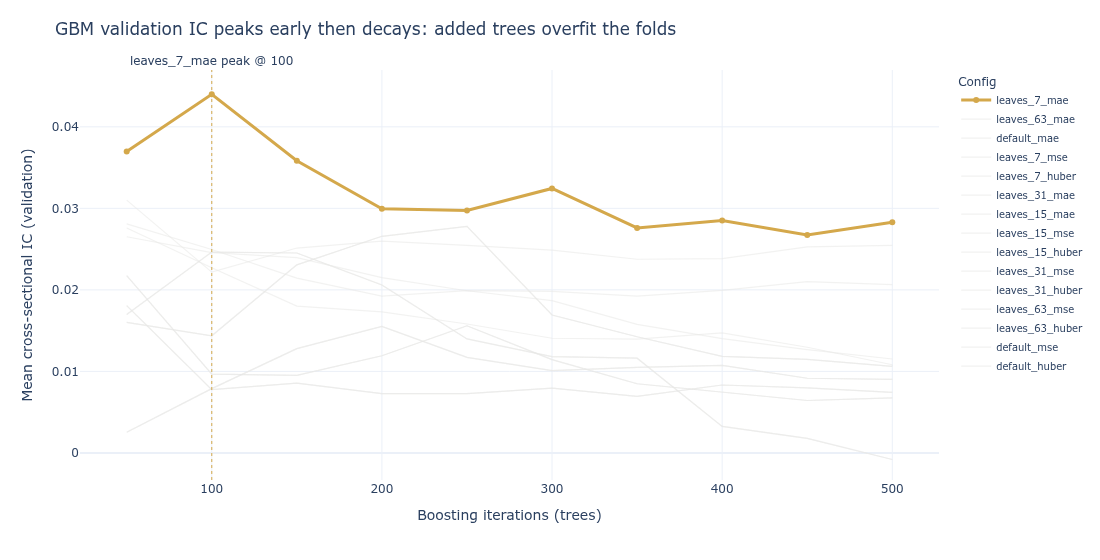

Config                         50     100     200     300     500
  leaves_7_mae              +0.0370 +0.0440 +0.0299 +0.0324 +0.0283
  leaves_63_mae             +0.0310 +0.0222 +0.0260 +0.0249 +0.0254
  default_mae               +0.0281 +0.0249 +0.0192 +0.0198 +0.0206
  leaves_7_mse              +0.0160 +0.0144 +0.0266 +0.0169 +0.0106
  leaves_7_huber            +0.0160 +0.0144 +0.0266 +0.0169 +0.0106
  leaves_31_mae             +0.0276 +0.0227 +0.0173 +0.0141 +0.0108
  leaves_15_mae             +0.0265 +0.0246 +0.0215 +0.0187 +0.0115
  leaves_15_mse             +0.0170 +0.0246 +0.0206 +0.0118 -0.0008
  leaves_15_huber           +0.0170 +0.0246 +0.0206 +0.0118 -0.0008
  leaves_31_mse             +0.0217 +0.0097 +0.0119 +0.0114 +0.0068
  leaves_31_huber           +0.0217 +0.0097 +0.0119 +0.0114 +0.0068
  leaves_63_mse             +0.0181 +0.0077 +0.0073 +0.0079 +0.0074
  leaves_63_huber           +0.0181 +0.0077 +0.0073 +0.0079 +0.0074
  default_mse               +0.0025 +0.0079 +0.015

In [10]:
all_curves = pl.DataFrame([c for r in results for c in r["learning_curves"]])
if all_curves.height > 0:
    # Figure 2 - checkpoint learning curves (IC vs iteration), winner highlighted.
    fig_lc = go.Figure()
    for r in results:
        cfg_data = all_curves.filter(pl.col("config") == r["config_name"]).sort("iteration")
        if cfg_data.height == 0:
            continue
        is_winner = best is not None and r["config_name"] == best["config_name"]
        fig_lc.add_trace(
            go.Scatter(
                x=cfg_data["iteration"].to_list(),
                y=cfg_data["ic_mean"].to_list(),
                mode="lines+markers" if is_winner else "lines",
                name=r["config_name"],
                line=dict(
                    color=COLORS["amber"] if is_winner else COLORS["silver_muted"],
                    width=3 if is_winner else 1.2,
                ),
                marker=dict(size=6),
                opacity=1.0 if is_winner else 0.55,
            )
        )
    if best is not None:
        fig_lc.add_vline(
            x=best["best_iter"],
            line=dict(color=COLORS["amber"], width=1, dash="dot"),
            annotation_text=f"{best['config_name']} peak @ {best['best_iter']}",
            annotation_position="top",
        )
    fig_lc.update_layout(
        title="GBM validation IC peaks early then decays: added trees overfit the folds",
        template="plotly_white",
        height=560,
        width=1100,
        legend=dict(title="Config", font=dict(size=10)),
        margin=dict(t=70),
    )
    fig_lc.update_xaxes(title_text="Boosting iterations (trees)")
    fig_lc.update_yaxes(title_text="Mean cross-sectional IC (validation)")
    fig_lc.show()

    # Compact checkpoint table for the exact values behind the curves.
    checkpoints = sorted(all_curves["iteration"].unique().to_list())
    display_cps = [cp for cp in [50, 100, 200, 300, 500] if cp in checkpoints]

    print(f"{'Config':25s}", end="")
    for cp in display_cps:
        print(f" {cp:>7d}", end="")
    print()

    for r in results:
        cfg_data = all_curves.filter(pl.col("config") == r["config_name"])
        print(f"  {r['config_name']:25s}", end="")
        for cp in display_cps:
            row = cfg_data.filter(pl.col("iteration") == cp)
            if row.height > 0:
                print(f" {row['ic_mean'][0]:+7.4f}", end="")
            else:
                print(f" {'N/A':>7s}", end="")
        print()

## 6. Registration Complete

Each config was registered immediately after training (see Section 3).
This protects against interruption - all completed configs are already
persisted in `run_log/registry.db`.

In [11]:
print(f"All {len(results)} configs registered.")

All 15 configs registered.


## 7. Key Takeaways

- **Shallow trees with MAE loss lead.** `leaves_7_mae` is the full-coverage
  winner at validation IC $\approx +0.044$ (peak at 100 trees), and the MAE-loss
  configs occupy the top of the ranking. Squared-error and Huber losses, and the
  deepest trees (`leaves_63`), trail down to $\approx +0.016$. On a 99-symbol
  cross-section the outlier-robust MAE objective and aggressive regularization
  (few leaves, few trees) transfer better than high-capacity settings.
- **GBM modestly edges the linear leader, not decisively.** The best GBM
  ($\approx +0.044$) is a hair above the full-coverage linear leader, Ridge at
  $\alpha = 10^6$ ($\approx +0.042$ from [`06_linear`](06_linear.ipynb)). The
  gain from non-linearity is real but small: the cross-asset signal is largely
  linear, and the HMM stress state does not open up non-linear splits that lift
  IC by much. Both models sit in the same $+0.04$ neighborhood.
- **Capacity overfits the folds.** The learning curves peak early (the winner at
  100 trees) and decay - added trees fit fold-specific noise, not transferable
  cross-sectional structure. Tree count is tuned on the validation folds via the
  shared checkpoint grid, the analogue of early stopping; the holdout is untouched.

The narrow GBM-over-linear edge motivates the move to temporal models in Ch13:
TSMixer captures lead-lag dynamics across the 9 asset classes (e.g., TLT leading
equity volatility), a form of structure that neither linear models nor a
cross-sectional GBM can exploit.

**Next**: [`08_tabular_dl`](08_tabular_dl.ipynb) tests TabM as a bridge between linear and
sequence models; [`10_dl_tsmixer`](10_dl_tsmixer.ipynb) applies channel-mixing to the
cross-asset temporal structure.